## Homogeneous BRDF

Estimation of diffuse color using Metropolis-Hastings without gradient

In [1]:
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image

In [2]:
import torch

In [3]:
scene = Scene()
diffuse_gt = (0.7, 0.5, 0.2)
diffuse = diffuse_gt
black = (0,0,0)
scene.set('mat', DiffuseBRDF(diffuse))
scene.set('black', DiffuseBRDF(black))
scene.set('mesh1', Mesh.from_file("quad.obj", 'mat')) # surface to reconstruct
scene.set('mesh2', Mesh.from_file("light.obj", 'black', radiance=400)) # area light source
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('path', {'max_depth': 3, 'hide_emitters': True}))
scene.set('cam1', PerspectiveCamera.from_lookat(fov=30, origin=(3,3,0), target=(0,0,0), up=(0,1,0))) # camera

In [4]:
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 1,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't allow changing spp, workaround here to render a 128-spp target image
# I_t = renderer(scene)
I_t = torch.cat([renderer(scene) for _ in range(128)]).mean(axis=0).unsqueeze(dim=0)

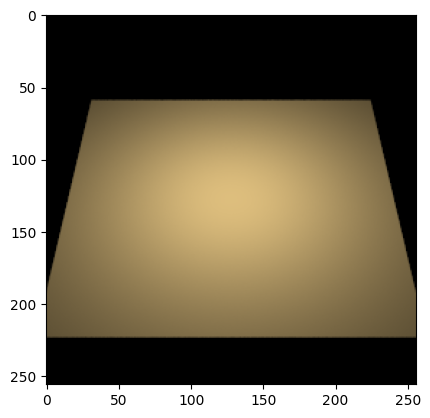

In [5]:
# Visualize the target Image
from matplotlib import pyplot as plt
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
def showhist(a):
    plt.hist(a.view(-1).detach().cpu().numpy(), bins=100)
showimg(I_t)

### Parameter Mapping & Prior Distribution

To make sure parameters are in proper range and avoid dealing with clipping samples, we map parameters from a finite range into the entire real number range. Specifically in this experiment, the *original parameters* are all in range (0,1) denoted as x. We map them into (-inf,inf) using the formula y=logit(x). Invert it, we have x=sigmoid(y). We call y *normalized parameter*.

We're assuming uniform prior distribution in the parametric space x~U[0,1]. After the inverse sigmoid mapping, the prior distribution in (-inf,inf) should be pdf(y) = x*(1-x) = sigmoid(y) * (1-sigmoid(y)).

Note that for numerical stability and convenience for sampling, all pdfs are represented as -log(pdf).

In [6]:
# To avoid clipping, we are mapping parameters from a finite range (0,1) to (-inf,inf)
def orig_to_norm(x):
    return torch.log(x/(1-x))

def norm_to_orig(y):
    return torch.sigmoid(y)

In [7]:
def logpdf_prior(x): # here x is normalized parameter (tensor)
    xo = norm_to_orig(x)
    return -(xo * (1-xo)).log().sum(axis=-1) # multiplied over all channels

### Loss Function (Likelihood)

Because we're reconstructing the texture for an exact match, we can simply use per-pixel loss in the image space.

In [8]:
def logpdf(img):
    from math import sqrt, pi
    sigma = torch.tensor(0.02)
    # log of density of a normal distribution
    lpdf = ((img - I_t).pow(2.0)/(2.0*sigma.pow(2.0)) + \
                (sqrt(2*pi)*sigma).log()).mean()
    return lpdf

### Posterior Probability

In [9]:
def U_orig(xo):
    scene['mat']['d'] = xo
    img = renderer(scene)
    lpdf = logpdf(img)
    return lpdf, img

# potential energy in the normalized parametric space
def U(x):
    scene['mat']['d'] = norm_to_orig(x)
    img = renderer(scene)
    lpdf = logpdf(img) + logpdf_prior(x)
    return lpdf, img

### Metropolis-Hastings

In [10]:
from tqdm import tqdm
import time
from torch.distributions import Normal

In [18]:
class MH:
    def __init__(self):
        self.num_accepts = 0
        self.num_rejects = 0
        self.xs = []
        self.Us = []
    
    def proposal(self, x0, U0):
        distr = Normal(x0, 0.5)
        x_tmp = distr.sample()
        U_tmp, _ = U(x_tmp)
        arej = torch.exp((U0-U_tmp).clamp(max=88))
        return arej, x_tmp, U_tmp

    def sample(self, x0, nsamples=1000):
        U0, _ = U(x0)
        for i in tqdm(range(nsamples)):
            # generate proposal sample
            arej, x_tmp, U_tmp = self.proposal(x0, U0)
            # accept or reject proposal on a per-pixel basis
            accepts = torch.bernoulli(arej.clamp_max(1)).bool()
            self.num_accepts += accepts
            if accepts:
                x0 = x_tmp
                U0 = U_tmp
#             x0 = torch.where(accepts.unsqueeze(-1), x_tmp, x0).detach()
            self.xs.append(x0)
            self.Us.append(U0)

In [21]:
mcmc = MH()

x0 = orig_to_norm(torch.empty_like(scene['mat']['d']).uniform_(0, 1))
mcmc.sample(x0, nsamples=5000)

100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:25<00:00, 58.34it/s]


In [22]:
mcmc.num_accepts

tensor(1822, device='cuda:0')

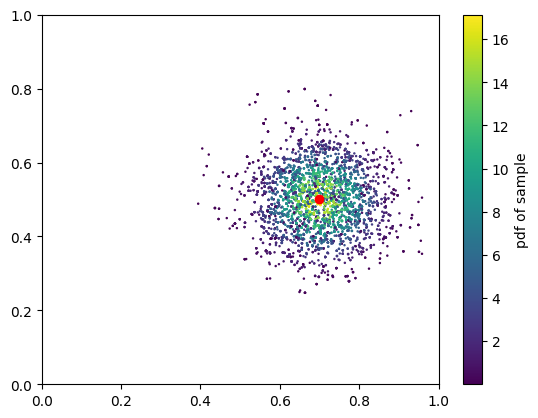

In [24]:
# Visualize these samples in original parametric space
axes = [0, 1]
xs = []
ys = []
zs = []
for i,p in enumerate(mcmc.xs):
    po = norm_to_orig(p)
    xs.append(po.cpu()[axes[0]])
    ys.append(po.cpu()[axes[1]])
    u = mcmc.Us[i] - (-(po * (1-po)).log().sum(axis=-1))
    zs.append((-u).exp().cpu())

# plt.figure(figsize=(8, 6))
plt.scatter(xs, ys, c=zs, s=0.6)
# plt.scatter(xs, ys, c=zs, s=0.2)
plt.xlim(0, 1)
plt.ylim(0, 1)
cbar = plt.colorbar()
cbar.set_label('pdf of sample')


# visualize the ground truth
# gt = orig_to_norm(torch.tensor(diffuse_gt))
plt.scatter(diffuse_gt[axes[0]], diffuse_gt[axes[1]], color='red')


# overlay contour of posterior distribution in a cross section (which isn't equivalent to marginal distribution)


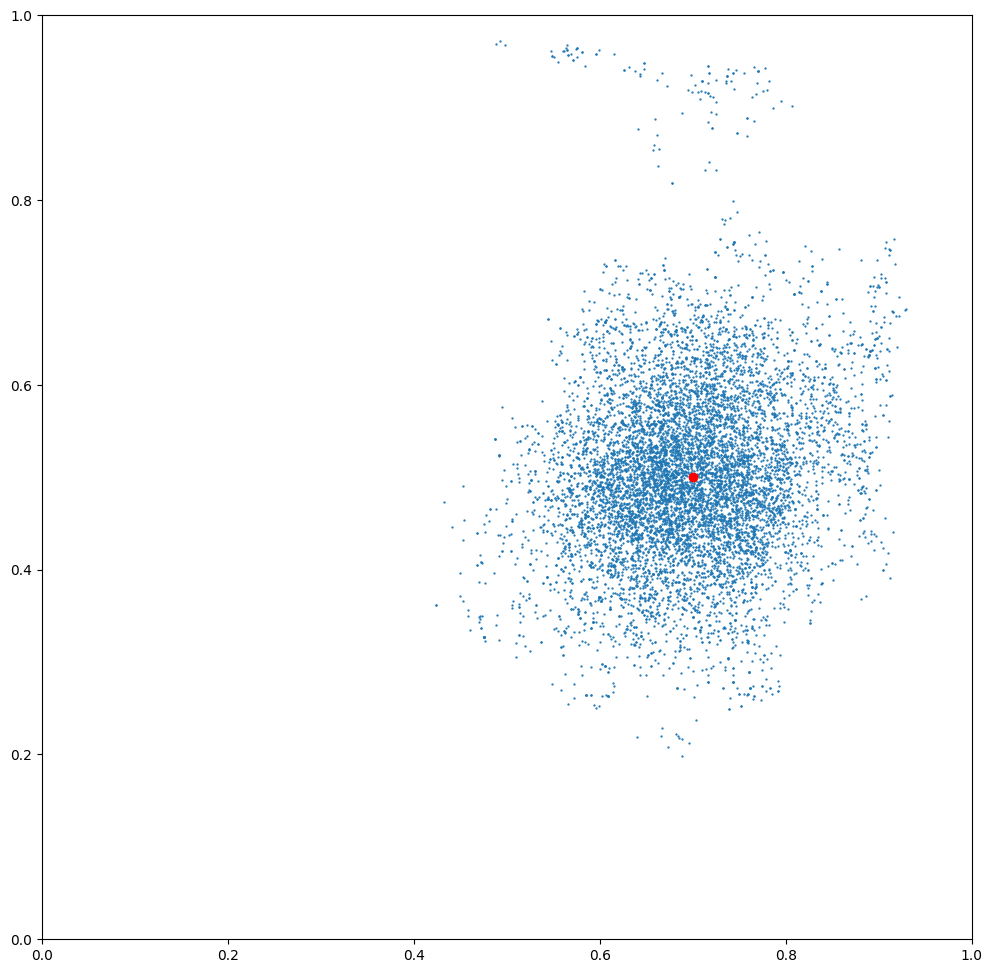

In [96]:
# Visualize these samples in original parametric space
axes = [0, 1]
xs = []
ys = []
zs = []
for i,p in enumerate(mcmc.xs):
    po = norm_to_orig(p)
    xs.append(po.cpu()[axes[0]])
    ys.append(po.cpu()[axes[1]])
    u = mcmc.Us[i] - (-(po * (1-po)).log().sum(axis=-1))
    zs.append((-u).exp().cpu())

plt.figure(figsize=(12, 12))
plt.scatter(xs, ys, s=0.4)
plt.xlim(0, 1)
plt.ylim(0, 1)

# visualize the ground truth
# gt = orig_to_norm(torch.tensor(diffuse_gt))
plt.scatter(diffuse_gt[axes[0]], diffuse_gt[axes[1]], color='red')


### Visualize Posterior Distribution

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:25<00:00,  1.58it/s]


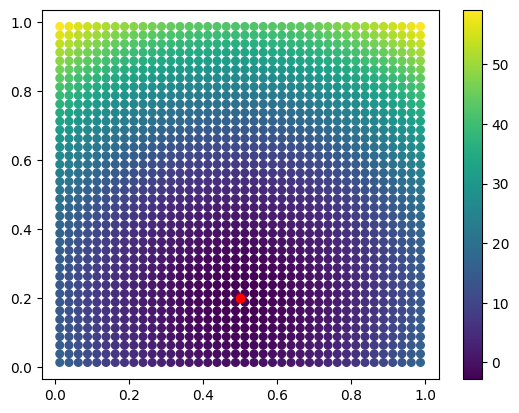

In [66]:
# generate a uniform grid on a slice of the original parametric space (blue=0.2)
# to visualize the posterior distribution
first_components = []
second_components = []
Us = []
res = 40
for i in tqdm(range(res)):
    for j in range(res):
        x = i/res + 0.5/res
        y = j/res + 0.5/res
        first_components.append(x)
        second_components.append(y)
        p = [0,0,0]
        gtax = (set([0,1,2]) - set(axes)).pop()
        p[gtax] = diffuse_gt[gtax]
        p[axes[0]] = x
        p[axes[1]] = y
        Us.append(U_orig(torch.tensor(p).cuda())[0].item())
        
plt.scatter(first_components, second_components, c=Us, s=30)
plt.colorbar()
# visualize the ground truth
plt.scatter(diffuse_gt[axes[0]], diffuse_gt[axes[1]], color='red')

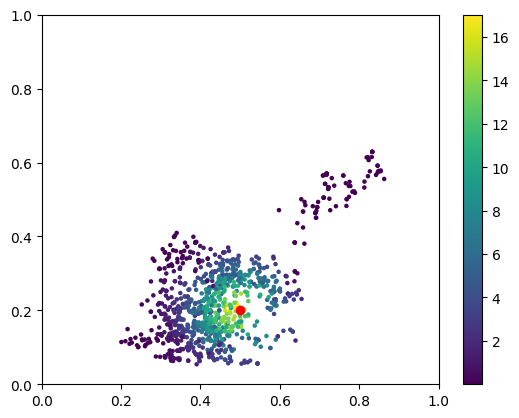

In [73]:
# Visualize these samples in original parametric space
axes = [1, 2]
xs = []
ys = []
zs = []
for i,p in enumerate(mcmc.xs):
    po = norm_to_orig(p)
    xs.append(po.cpu()[axes[0]])
    ys.append(po.cpu()[axes[1]])
    u = mcmc.Us[i] - (-(po * (1-po)).log().sum(axis=-1))
    zs.append((-u).exp().cpu())

plt.scatter(xs, ys, c=zs, s=5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.colorbar()

# visualize the ground truth
# gt = orig_to_norm(torch.tensor(diffuse_gt))
plt.scatter(diffuse_gt[axes[0]], diffuse_gt[axes[1]], color='red')


# overlay contour of posterior distribution in a cross section (which isn't equivalent to marginal distribution)

# plt.contour(torch.tensor(first_components).reshape((res,res)),
#             torch.tensor(second_components).reshape((res,res)),
#             (-torch.tensor(Us)).exp().reshape((res,res)),
#             10)

In [53]:
(-torch.tensor(Us)).exp().reshape((res,res))

tensor([[1.2417e-21, 6.8600e-21, 3.4601e-20,  ..., 2.9747e-20, 5.8190e-21,
         1.0383e-21],
        [1.4101e-20, 7.7903e-20, 3.9265e-19,  ..., 3.3624e-19, 6.7101e-20,
         1.1764e-20],
        [1.4603e-19, 8.0604e-19, 4.0501e-18,  ..., 3.4405e-18, 7.0129e-19,
         1.2181e-19],
        ...,
        [1.0967e-08, 6.0285e-08, 3.0371e-07,  ..., 2.5334e-07, 4.9822e-08,
         9.2021e-09],
        [4.4256e-09, 2.3909e-08, 1.2239e-07,  ..., 1.0540e-07, 2.1138e-08,
         3.6384e-09],
        [1.6220e-09, 9.1444e-09, 4.5088e-08,  ..., 4.0014e-08, 7.5643e-09,
         1.3808e-09]])

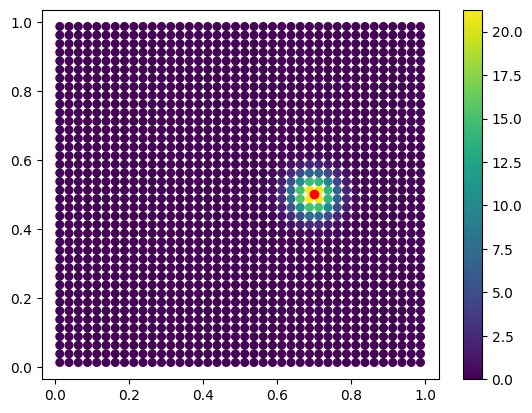

In [57]:

plt.scatter(first_components, second_components, c=[math.exp(-u.cpu()) for u in Us], s=30)
plt.colorbar()
# visualize the ground truth
plt.scatter(diffuse_gt[0], diffuse_gt[1], color='red')